In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from src.scratch_ann_model_with_p import training_two_layer_ann, calculate_accuracy
from src.utils import plot_value_per_epoch
import matplotlib.pyplot as plt

In [3]:
df_train = pd.read_csv('../data/fashion-mnist_train.csv')
df_test = pd.read_csv('../data/fashion-mnist_test.csv')

In [4]:
scaler = MinMaxScaler()
labels = df_train.pop('label')
inputs = scaler.fit_transform(df_train.values)

In [5]:
y_test = df_test.pop('label')
x_test = scaler.fit_transform(df_test)

In [6]:
wl1, wl2, b1, b2, loss, epoch_no, time_per_epoch = training_two_layer_ann(inputs, labels, n_hidden=128, output_size=10, beta = 0, learning_rate=0.01, batch_size=16, n_epochs=200)

Epoch 1/200, Loss: 0.6341, Time: 0.69s
Epoch 2/200, Loss: 0.4676, Time: 0.72s
Epoch 3/200, Loss: 0.4287, Time: 0.75s
Epoch 4/200, Loss: 0.4044, Time: 0.71s
Epoch 5/200, Loss: 0.3864, Time: 0.68s
Epoch 6/200, Loss: 0.3720, Time: 0.69s
Epoch 7/200, Loss: 0.3601, Time: 0.69s
Epoch 8/200, Loss: 0.3496, Time: 0.68s
Epoch 9/200, Loss: 0.3404, Time: 0.68s
Epoch 10/200, Loss: 0.3322, Time: 0.69s
Epoch 11/200, Loss: 0.3247, Time: 0.68s
Epoch 12/200, Loss: 0.3178, Time: 0.68s
Epoch 13/200, Loss: 0.3113, Time: 0.68s
Epoch 14/200, Loss: 0.3054, Time: 0.68s
Epoch 15/200, Loss: 0.3000, Time: 0.69s
Epoch 16/200, Loss: 0.2948, Time: 0.73s
Epoch 17/200, Loss: 0.2901, Time: 0.68s
Epoch 18/200, Loss: 0.2856, Time: 0.69s
Epoch 19/200, Loss: 0.2813, Time: 0.68s
Epoch 20/200, Loss: 0.2772, Time: 0.68s
Epoch 21/200, Loss: 0.2733, Time: 0.69s
Epoch 22/200, Loss: 0.2694, Time: 0.87s
Epoch 23/200, Loss: 0.2656, Time: 0.69s
Epoch 24/200, Loss: 0.2621, Time: 0.71s
Epoch 25/200, Loss: 0.2588, Time: 0.73s
Epoch 26/

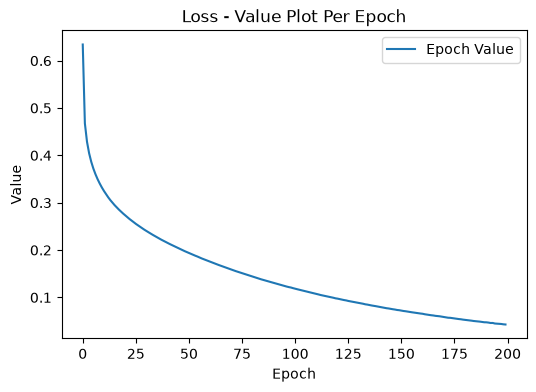

np.float64(0.8892)

In [7]:
plot_value_per_epoch(loss, title="Loss")
calculate_accuracy(wl1, wl2, b1, b2, x_test, y_test)

In [8]:
wl1, wl2, b1, b2, loss, epoch_no, time_per_epoch = training_two_layer_ann(inputs, labels, n_hidden=128, output_size=10, learning_rate=0.01, batch_size=16, n_epochs=200)

Epoch 1/200, Loss: 0.5112, Time: 0.74s
Epoch 2/200, Loss: 0.3934, Time: 0.68s
Epoch 3/200, Loss: 0.3582, Time: 0.69s
Epoch 4/200, Loss: 0.3343, Time: 0.69s
Epoch 5/200, Loss: 0.3186, Time: 0.71s
Epoch 6/200, Loss: 0.3044, Time: 0.70s
Epoch 7/200, Loss: 0.2914, Time: 0.72s
Epoch 8/200, Loss: 0.2803, Time: 0.72s
Epoch 9/200, Loss: 0.2709, Time: 0.68s
Epoch 10/200, Loss: 0.2630, Time: 0.68s
Epoch 11/200, Loss: 0.2560, Time: 0.72s
Epoch 12/200, Loss: 0.2475, Time: 0.68s
Epoch 13/200, Loss: 0.2411, Time: 0.68s
Epoch 14/200, Loss: 0.2342, Time: 0.68s
Epoch 15/200, Loss: 0.2291, Time: 0.68s
Epoch 16/200, Loss: 0.2250, Time: 0.68s
Epoch 17/200, Loss: 0.2188, Time: 0.69s
Epoch 18/200, Loss: 0.2141, Time: 0.70s
Epoch 19/200, Loss: 0.2096, Time: 0.71s
Epoch 20/200, Loss: 0.2038, Time: 0.69s
Epoch 21/200, Loss: 0.2001, Time: 0.74s
Epoch 22/200, Loss: 0.1967, Time: 0.70s
Epoch 23/200, Loss: 0.1909, Time: 0.76s
Epoch 24/200, Loss: 0.1885, Time: 0.71s
Epoch 25/200, Loss: 0.1838, Time: 0.68s
Epoch 26/

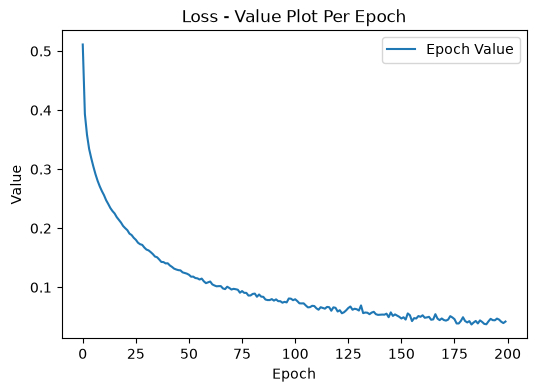

np.float64(0.8778)

In [9]:
plot_value_per_epoch(loss, title="Loss")
calculate_accuracy(wl1, wl2, b1, b2, x_test, y_test)

## Key Findings from the Scratch Implementation

During the custom NumPy implementation of a two-layer ANN, several critical mechanics of optimization were observed, The Importance of Weight Initialization specially.

Initializing weights with strictly positive random numbers (np.random.random()) caused massive initial gradients, resulting in the optimizer overcorrecting and pushing weights into deep negative territory. This caused "Dying ReLU" (a permanently dead network with flat loss). Implementing He Initialization (np.random.standard_normal() * sqrt(2/n)) fixed this entirely.

### The Impact of $\beta$ (Momentum Coefficient): 
* When $\beta = 0.9$, the loss smoothly and rapidly decayed to ~0.05 by epoch 200.
* When $\beta = 0.0$ (Vanilla SGD), the loss stalled around ~0.25 by epoch 200.

Conclusion: Momentum is strictly necessary for navigating flat loss landscapes efficiently when using standard gradient descent. But we also saw that with moemntum after almost raching the stable point it just keeps on oscillating around that due to which such oscillation are visible in the abpve graph